In [ ]:
import os
import numpy as np
import pandas as pd

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

from src.audio import extract_logmel
from src.models import MultiModalVAE, multimodal_vae_loss
from src.evaluation import evaluation_medium
from src.visualisation import plot_training_loss, plot_tsne

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('results_medium/plots', exist_ok=True)

In [2]:
TSV_PATH = 'data/sampled.tsv'
AUDIO_DIR = 'data/songs'

audio_X, lyrics, genres, languages = extract_logmel(TSV_PATH, AUDIO_DIR)

  0%|          | 0/1000 [00:00<?, ?it/s]/home/tanzim/miniconda3/envs/cse715-project/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1000/1000 [01:35<00:00, 10.45it/s]


In [11]:
# Vectorise lyrics
vectorizer = TfidfVectorizer(max_features=1000)
lyrics_X = vectorizer.fit_transform(lyrics).toarray()

# Normalise
scaler_text = StandardScaler()
lyrics_X = scaler_text.fit_transform(lyrics_X)

In [ ]:
# Normalise spectrogram
audio_X = (audio_X - np.mean(audio_X, axis=(1,2), keepdims=True)) / \
          (np.std(audio_X, axis=(1,2), keepdims=True) + 1e-8)

# Add channel dimension for CNN
audio_X = np.expand_dims(audio_X, axis=1)

# Convert to tensors
audio_tensor = torch.tensor(audio_X, dtype=torch.float32)
lyrics_tensor = torch.tensor(lyrics_X, dtype=torch.float32)

In [ ]:
LATENT_DIM = 32
EPOCHS = 50

# Text input dimension for model
text_dim = lyrics_X.shape[1]

# Construct model and use Adam optimiser with learning rate = 1e-3
model = MultiModalVAE(text_dim, latent_dim=LATENT_DIM).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

dataset = torch.utils.data.TensorDataset(audio_tensor, lyrics_tensor)
loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

loss_history = []

for epoch in range(EPOCHS):
    total_loss = 0

    for (audio, text) in loader:
        audio = audio.to(device)
        text = text.to(device)

        optimiser.zero_grad()

        audio_recon, text_recon, mu, logvar = model(audio, text)

        loss = multimodal_vae_loss(audio_recon, audio, text_recon, text, mu, logvar)

        loss.backward()
        optimiser.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

# Save model and loss history
torch.save(model.state_dict(), 'results_medium/conv_vae.pth')
np.save('results_medium/loss_history.npy', loss_history)

Epoch 1, Loss: 1.8933
Epoch 2, Loss: 1.4511
Epoch 3, Loss: 1.3842
Epoch 4, Loss: 1.3727
Epoch 5, Loss: 1.3707
Epoch 6, Loss: 1.3673
Epoch 7, Loss: 1.3664
Epoch 8, Loss: 1.3638
Epoch 9, Loss: 1.3629
Epoch 10, Loss: 1.3613
Epoch 11, Loss: 1.3630
Epoch 12, Loss: 1.3598
Epoch 13, Loss: 1.3606
Epoch 14, Loss: 1.3618
Epoch 15, Loss: 1.3612
Epoch 16, Loss: 1.3623
Epoch 17, Loss: 1.3601
Epoch 18, Loss: 1.3595
Epoch 19, Loss: 1.3613
Epoch 20, Loss: 1.3593
Epoch 21, Loss: 1.3588
Epoch 22, Loss: 1.3589
Epoch 23, Loss: 1.3596
Epoch 24, Loss: 1.3582
Epoch 25, Loss: 1.3582
Epoch 26, Loss: 1.3574
Epoch 27, Loss: 1.3589
Epoch 28, Loss: 1.3580
Epoch 29, Loss: 1.3594
Epoch 30, Loss: 1.3588
Epoch 31, Loss: 1.3578
Epoch 32, Loss: 1.3579
Epoch 33, Loss: 1.3575
Epoch 34, Loss: 1.3572
Epoch 35, Loss: 1.3589
Epoch 36, Loss: 1.3571
Epoch 37, Loss: 1.3572
Epoch 38, Loss: 1.3578
Epoch 39, Loss: 1.3571
Epoch 40, Loss: 1.3571
Epoch 41, Loss: 1.3570
Epoch 42, Loss: 1.3566
Epoch 43, Loss: 1.3583
Epoch 44, Loss: 1.35

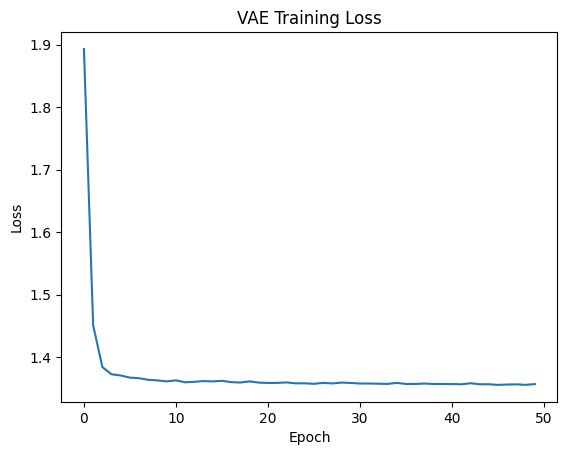

In [6]:
# Plot training loss and save figure
plot_training_loss(loss_history, 'results_medium/plots/loss_curve.svg')

In [ ]:
# Get model outputs for evaluation
model.eval()
with torch.no_grad():
    mu_a, _ = model.encode_audio(audio_tensor.to(device))
    mu_t, _ = model.encode_text(lyrics_tensor.to(device))

    # Simply take mean of audio and text
    Z = ((mu_a + mu_t) / 2).cpu().numpy()

In [ ]:
# Flatten audio spectrograms for PCA
audio_flat = audio_X.reshape(audio_X.shape[0], -1)

# Normalize audio before PCA
audio_flat_scaled = StandardScaler().fit_transform(audio_flat)

# Raw combined for baseline comparison
Z_raw_combined = np.concatenate([audio_flat_scaled, lyrics_X], axis=1)

# PCA
pca = PCA(n_components=LATENT_DIM, random_state=27)
Z_pca_combined = pca.fit_transform(Z_raw_combined)

In [ ]:
results = []

for k, label_type, labels in [
    (2, 'language', languages),
    (6, 'genre', genres)
]:
    # Raw features
    _, _, _, _, sil_kmeans_raw, ch_kmeans_raw, d_kmeans_raw, ari_kmeans_raw, sil_agglo_raw, ch_agglo_raw, d_agglo_raw, ari_agglo_raw = evaluation_medium(Z_raw_combined, labels, k)
    
    # Text only features
    _, _, _, _, sil_kmeans_text, ch_kmeans_text, d_kmeans_text, ari_kmeans_text, sil_agglo_text, ch_agglo_text, d_agglo_text, ari_agglo_text = evaluation_medium(lyrics_X, labels, k)
    
    # PCA features
    _, _, _, _, sil_kmeans_pca, ch_kmeans_pca, d_kmeans_pca, ari_kmeans_pca, sil_agglo_pca, ch_agglo_pca, d_agglo_pca, ari_agglo_pca = evaluation_medium(Z_pca_combined, labels, k)
    
    # VAE features
    _, _, _, _, sil_kmeans_vae, ch_kmeans_vae, d_kmeans_vae, ari_kmeans_vae, sil_agglo_vae, ch_agglo_vae, d_agglo_vae, ari_agglo_vae = evaluation_medium(Z, labels, k)

    results.append([k, label_type, 'RAW', sil_kmeans_raw, ch_kmeans_raw, d_kmeans_raw, ari_kmeans_raw, sil_agglo_raw, ch_agglo_raw, d_agglo_raw, ari_agglo_raw])
    results.append([k, label_type, 'TEXT', sil_kmeans_text, ch_kmeans_text, d_kmeans_text, ari_kmeans_text, sil_agglo_text, ch_agglo_text, d_agglo_text, ari_agglo_text])
    results.append([k, label_type, 'PCA', sil_kmeans_pca, ch_kmeans_pca, d_kmeans_pca, ari_kmeans_pca, sil_agglo_pca, ch_agglo_pca, d_agglo_pca, ari_agglo_pca])
    results.append([k, label_type, 'VAE', sil_kmeans_vae, ch_kmeans_vae, d_kmeans_vae, ari_kmeans_vae, sil_agglo_vae, ch_agglo_vae, d_agglo_vae, ari_agglo_vae])

df_results = pd.DataFrame(results, columns=['k', 'label_type', 'method', 'silhouette_kmeans', 'calinski_harabasz_kmeans', 'davies_bouldin_kmeans', 'ari_kmeans', 'silhouette_agglo', 'calinski_harabasz_agglo', 'davies_bouldin_agglo', 'ari_agglo'])
df_results.to_csv('results_medium/clustering_metrics.csv', index=False)

df_results

,k,label_type,method,silhouette_kmeans,calinski_harabasz_kmeans,davies_bouldin_kmeans,ari_kmeans,silhouette_agglo,calinski_harabasz_agglo,davies_bouldin_agglo,ari_agglo
0,2,language,RAW,0.032741,37.823887,5.039497,0.003104,0.033942,27.084337,6.008653,0.006409
1,2,language,TEXT,0.033379,35.081407,5.273391,0.948625,0.032281,33.888295,5.367428,0.898603
2,2,language,PCA,0.095173,114.059346,2.812304,0.002608,0.078953,65.891541,2.529995,-0.000094
3,2,language,VAE,0.233486,346.034158,1.573215,0.002403,0.161859,212.177830,1.992047,0.001327
4,6,genre,RAW,0.004081,14.549741,5.316521,0.032903,-0.018953,12.863120,6.223719,0.024110
5,6,genre,TEXT,0.003135,8.894968,9.013596,0.001511,0.009210,9.159694,3.344512,0.036332
6,6,genre,PCA,0.040223,52.262725,3.182159,0.027436,0.006466,38.873196,3.667739,0.028812
7,6,genre,VAE,0.141751,220.687674,1.592999,0.012901,0.118831,182.659518,1.802359,0.029924


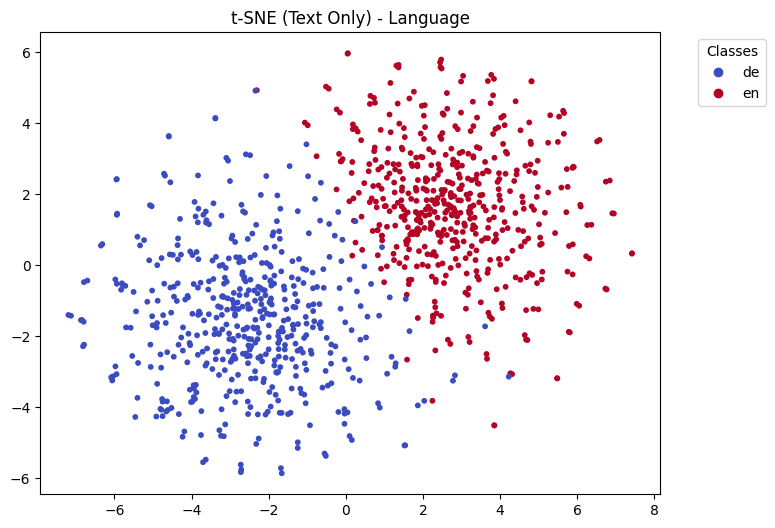

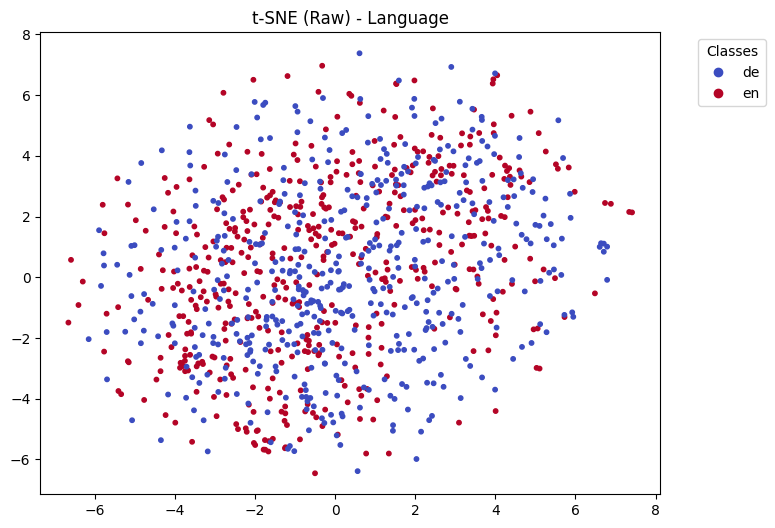

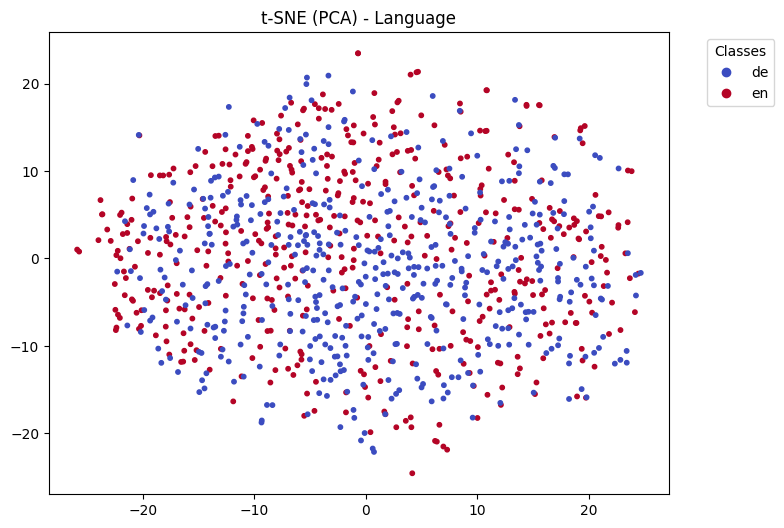

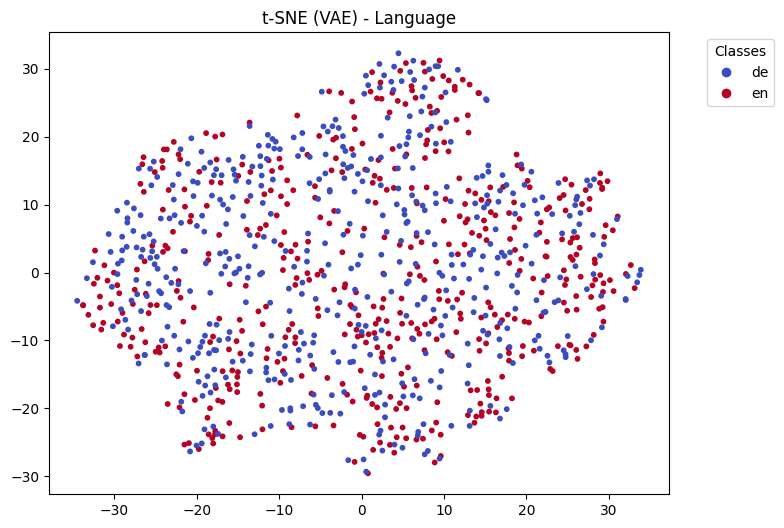

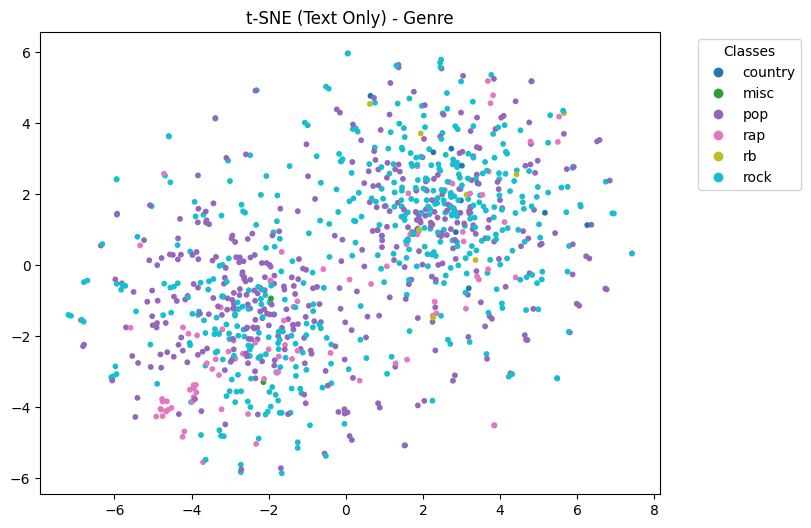

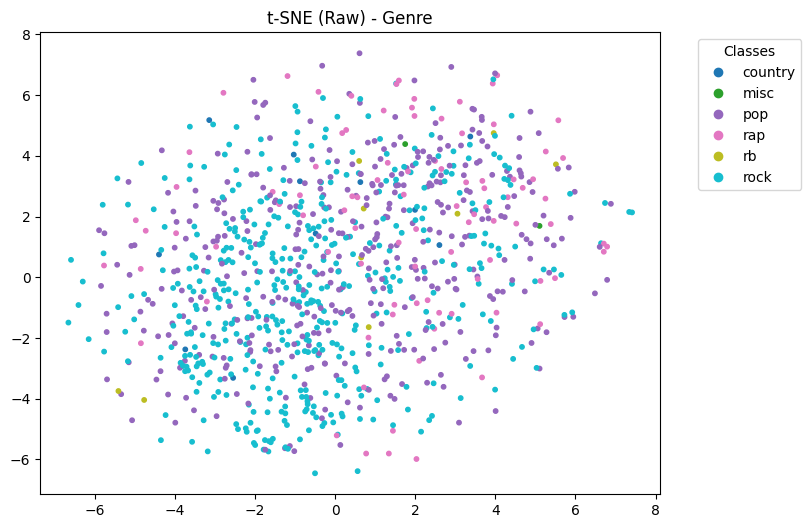

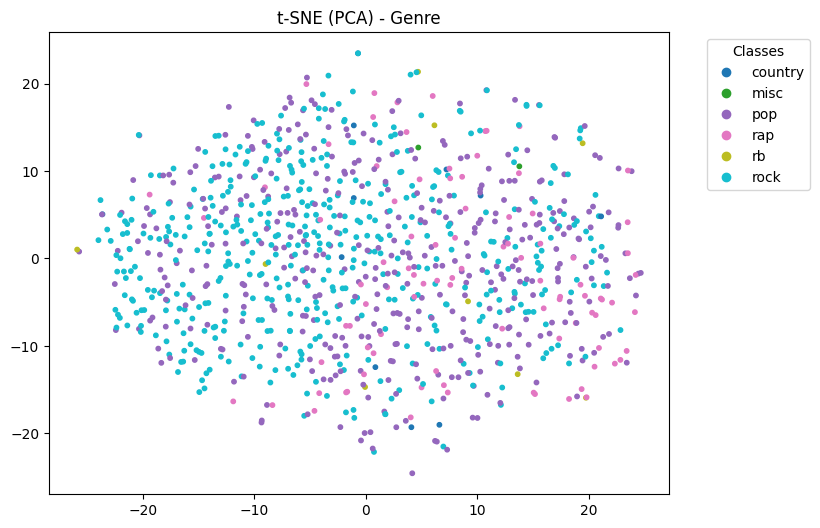

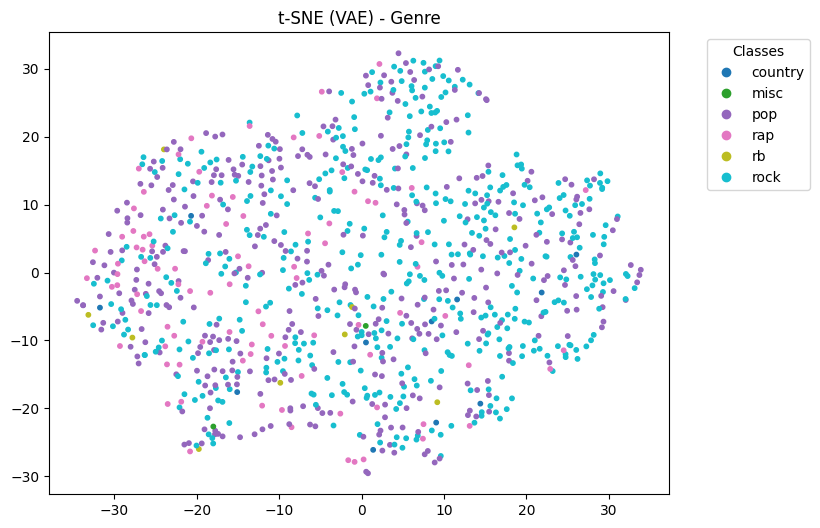

In [13]:
plot_tsne(lyrics_X, languages, 't-SNE (Text Only) - Language', 'results_medium/plots/tsne_language_text.svg', cmap_name='coolwarm')
plot_tsne(Z_raw_combined, languages, 't-SNE (Raw) - Language', 'results_medium/plots/tsne_language_raw.svg', cmap_name='coolwarm')
plot_tsne(Z_pca_combined, languages, 't-SNE (PCA) - Language', 'results_medium/plots/tsne_language_pca.svg', cmap_name='coolwarm')
plot_tsne(Z, languages, 't-SNE (VAE) - Language', 'results_medium/plots/tsne_language_vae.svg', cmap_name='coolwarm')

plot_tsne(lyrics_X, genres, 't-SNE (Text Only) - Genre', 'results_medium/plots/tsne_genre_text.svg', cmap_name='tab10')
plot_tsne(Z_raw_combined, genres, 't-SNE (Raw) - Genre', 'results_medium/plots/tsne_genre_raw.svg', cmap_name='tab10')
plot_tsne(Z_pca_combined, genres, 't-SNE (PCA) - Genre', 'results_medium/plots/tsne_genre_pca.svg', cmap_name='tab10')
plot_tsne(Z, genres, 't-SNE (VAE) - Genre', 'results_medium/plots/tsne_genre_vae.svg', cmap_name='tab10')